<a href="https://colab.research.google.com/github/nagavamshi506-ui/Telco-customer-churn/blob/main/telco_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import functions

In [1]:
!unzip "/content/archive (3).zip"

Archive:  /content/archive (3).zip
  inflating: Telco_customer_churn.xlsx  


In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

load the dataset

In [3]:
df = pd.read_excel('/content/Telco_customer_churn.xlsx')
print(df.head())
df.tail()

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


In [4]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [5]:
df.groupby('Online Backup')['Churn Label'].value_counts()

Online Backup        Churn Label
No                   No             1855
                     Yes            1233
No internet service  No             1413
                     Yes             113
Yes                  No             1906
                     Yes             523
Name: count, dtype: int64

In [6]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [7]:
df['Churn Reason']=df['Churn Reason'].fillna('No Reason')

In [8]:
df['Churn Reason'].isnull().sum()

np.int64(0)

In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])

In [10]:
df['Gender']
#0=male , 1=female

,Gender
0,1
1,0
2,0
3,0
4,1
...,...
7038,0
7039,1
7040,0
7041,0


In [11]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [12]:
df['Churn Label'].value_counts(normalize=True)

,proportion
Churn Label,
No,0.73463
Yes,0.26537


In [13]:
numeric_col=df.select_dtypes(include=['int64','float64']).columns
print(numeric_col)

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Gender', 'Tenure Months',
       'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='object')


Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


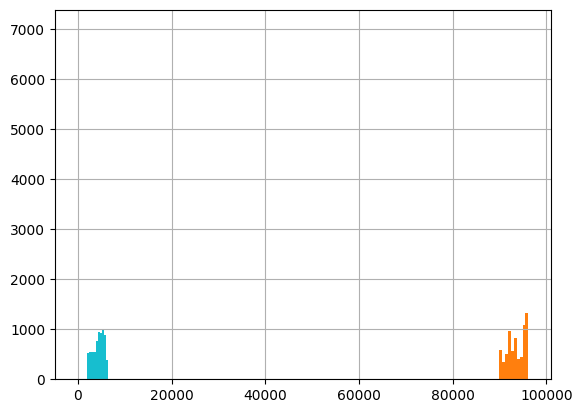

In [14]:
for col in numeric_col:
  print(df[col].hist())

array([[<Axes: title={'center': 'Tenure Months'}>,
        <Axes: title={'center': 'Monthly Charges'}>],
       [<Axes: title={'center': 'CLTV'}>,
        <Axes: title={'center': 'Churn Score'}>]], dtype=object)

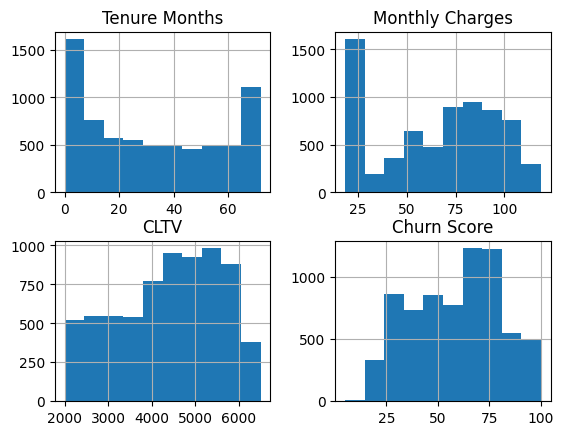

In [15]:
df[['Tenure Months','Monthly Charges','CLTV','Churn Score']].hist()

In [16]:
df.groupby('Churn Label')['Monthly Charges'].mean()
#13 units pay more by the people who has been churned

,Monthly Charges
Churn Label,
No,61.265124
Yes,74.441332


In [17]:
for col in ['Contract','Internet Service','Payment Method','Senior Citizen']:
    print(df.groupby(col)['Churn Value'].mean())

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn Value, dtype: float64
Internet Service
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn Value, dtype: float64
Payment Method
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn Value, dtype: float64
Senior Citizen
No     0.236062
Yes    0.416813
Name: Churn Value, dtype: float64


drop the unnecessary columns

In [18]:
df.drop(columns=['CustomerID','City', 'Count', 'Country', 'State',
        'Zip Code', 'Latitude', 'Longitude',
        'Churn Value', 'Churn Reason'],
        inplace=True,
        errors='ignore')
df.head()

,Lat Long,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Score,CLTV
0,"33.964131, -118.272783",1,No,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,86,3239
1,"34.059281, -118.30742",0,No,No,Yes,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,67,2701
2,"34.048013, -118.293953",0,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,86,5372
3,"34.062125, -118.315709",0,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,84,5003
4,"34.039224, -118.266293",1,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,89,5340


In [19]:
# This shows you the exact list of string names in your DataFrame
print(df.columns.tolist())

['Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Score', 'CLTV']


In [20]:
# Strip any hidden leading/trailing whitespace from all column names
df.columns = df.columns.str.strip()

Encode the data

-->label Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
col_to_encode=['Gender','Senior Citizen','Partner','Dependents','Streaming TV','Streaming Movies','Phone Service','Paperless Billing','Churn Label','Online Security']
for col in col_to_encode:
  df[col]=le.fit_transform(df[col])
df.head()

,Lat Long,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Score,CLTV
0,"33.964131, -118.272783",1,0,0,0,2,1,No,DSL,2,...,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,86,3239
1,"34.059281, -118.30742",0,0,0,1,2,1,No,Fiber optic,0,...,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,67,2701
2,"34.048013, -118.293953",0,0,0,1,8,1,Yes,Fiber optic,0,...,2,2,Month-to-month,1,Electronic check,99.65,820.5,1,86,5372
3,"34.062125, -118.315709",0,0,1,1,28,1,Yes,Fiber optic,0,...,2,2,Month-to-month,1,Electronic check,104.80,3046.05,1,84,5003
4,"34.039224, -118.266293",1,0,0,1,49,1,Yes,Fiber optic,0,...,2,2,Month-to-month,1,Bank transfer (automatic),103.70,5036.3,1,89,5340


-->one-hot encoding


In [22]:
df.head()

,Lat Long,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Score,CLTV
0,"33.964131, -118.272783",1,0,0,0,2,1,No,DSL,2,...,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,86,3239
1,"34.059281, -118.30742",0,0,0,1,2,1,No,Fiber optic,0,...,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,67,2701
2,"34.048013, -118.293953",0,0,0,1,8,1,Yes,Fiber optic,0,...,2,2,Month-to-month,1,Electronic check,99.65,820.5,1,86,5372
3,"34.062125, -118.315709",0,0,1,1,28,1,Yes,Fiber optic,0,...,2,2,Month-to-month,1,Electronic check,104.80,3046.05,1,84,5003
4,"34.039224, -118.266293",1,0,0,1,49,1,Yes,Fiber optic,0,...,2,2,Month-to-month,1,Bank transfer (automatic),103.70,5036.3,1,89,5340


In [23]:
# 1. Drop the text 'Lat Long' column which isn't needed
df.drop(columns=['Lat Long'], inplace=True, errors='ignore')

# 2. Encode the 'Multiple Lines' column which is still raw text
df['Multiple Lines'] = le.fit_transform(df['Multiple Lines'])

# Check the final fully-numeric dataframe
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Score,CLTV
0,1,0,0,0,2,1,0,DSL,2,Yes,...,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,86,3239
1,0,0,0,1,2,1,0,Fiber optic,0,No,...,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,67,2701
2,0,0,0,1,8,1,2,Fiber optic,0,No,...,2,2,Month-to-month,1,Electronic check,99.65,820.5,1,86,5372
3,0,0,1,1,28,1,2,Fiber optic,0,No,...,2,2,Month-to-month,1,Electronic check,104.80,3046.05,1,84,5003
4,1,0,0,1,49,1,2,Fiber optic,0,Yes,...,2,2,Month-to-month,1,Bank transfer (automatic),103.70,5036.3,1,89,5340


In [24]:
df.drop(columns=['Churn Score'],inplace=True)

In [25]:
# 1. Clean 'Total Charges' and force it to be numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
# Fill NaN values with the median, as attempted by the user
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

# 2. Identify remaining object columns for one-hot encoding
# Exclude 'Churn Label' as it's the target and already encoded (0/1)
object_cols = df.select_dtypes(include='object').columns.tolist()
if 'Churn Label' in object_cols:
    object_cols.remove('Churn Label')

# Apply one-hot encoding to these remaining object columns
if object_cols:
    df_encoded = pd.get_dummies(df, columns=object_cols, drop_first=True, dtype=int)
else:
    df_encoded = df.copy() # No object columns left to encode

# 3. Check to ensure there are no 'object' text columns left
print("DataFrame dtypes after encoding:")
print(df_encoded.dtypes)

# Assign df_encoded back to df for consistency in subsequent steps
df = df_encoded

DataFrame dtypes after encoding:
Gender                                      int64
Senior Citizen                              int64
Partner                                     int64
Dependents                                  int64
Tenure Months                               int64
Phone Service                               int64
Multiple Lines                              int64
Online Security                             int64
Streaming TV                                int64
Streaming Movies                            int64
Paperless Billing                           int64
Monthly Charges                           float64
Total Charges                             float64
Churn Label                                 int64
CLTV                                        int64
Internet Service_Fiber optic                int64
Internet Service_No                         int64
Online Backup_No internet service           int64
Online Backup_Yes                           int64
Device Protection

Divide the data


In [26]:
X=df.drop(columns=('Churn Label'))
y=df['Churn Label']

Spilt and train the data


In [27]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)
X_train_scale=sc.fit_transform(X_train_smote)
X_test_scale=sc.transform(X_test)

load the model
and train  it with data

In [28]:
from xgboost import XGBClassifier
model=XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train_scale,y_train_smote)
y_pred=model.predict(X_test_scale)

Apply the metrics

0.7892122072391767
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1009
           1       0.63      0.64      0.63       400

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.79      0.79      0.79      1409



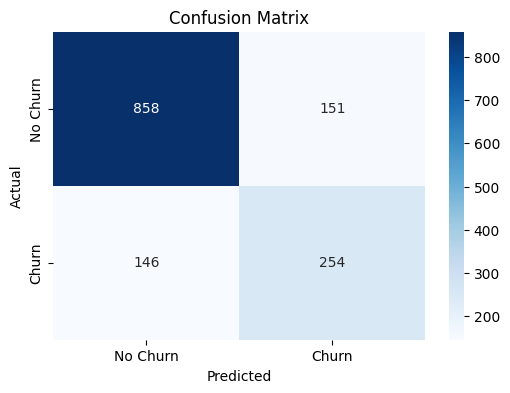

In [29]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
acc=accuracy_score(y_test,y_pred)
print(acc)
print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()